In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models
import matplotlib.pyplot as plt

class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 64, 3, 1, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, 1, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, 3, 1, 1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(256, 512, 3, 1, 1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        

        self.projection = nn.Sequential(
            nn.Linear(2048, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Linear(512, 128)
        )

        
        self.decoder_fc = nn.Linear(2048, 256 * 4 * 4)
        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1),  
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1),   
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1),   
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 3, 3, 1, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        flat = encoded.view(encoded.size(0), -1)
        projected = F.normalize(self.projection(flat), p=2, dim=1)
        x_recon = self.decoder_fc(flat)
        x_recon = x_recon.view(-1, 256, 4, 4)
        reconstruction = self.decoder_conv(x_recon)
        return reconstruction, projected



    

In [2]:
class SupConLoss(nn.Module):
    def __init__(self, temperature=0.07):
        super().__init__()
        self.temperature = temperature

    def forward(self, features, labels):
        device = features.device
        batch_size = features.shape[0]
        
        similarity_matrix = torch.matmul(features, features.T) / self.temperature
        
        labels = labels.contiguous().view(-1, 1)
        mask = torch.eq(labels, labels.T).float().to(device)
        self_mask = torch.eye(batch_size, dtype=torch.float32).to(device)
        mask = mask - self_mask
        
        max_sim, _ = torch.max(similarity_matrix, dim=1, keepdim=True)
        logits = similarity_matrix - max_sim.detach()
        
        exp_logits = torch.exp(logits)
        log_prob = logits - torch.log(exp_logits.sum(dim=1, keepdim=True) + 1e-10)
        
        mean_log_prob_pos = (mask * log_prob).sum(1) / (mask.sum(1) + 1e-10)
        mean_log_prob_pos = torch.nan_to_num(mean_log_prob_pos, nan=0.0)
        
        loss = -mean_log_prob_pos.mean()

        return loss

In [3]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

from torch.utils.data import Dataset
class MemoryDataset(Dataset):
    def __init__(self, dataset):
        self.data = [dataset[i] for i in range(len(dataset))]
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        return self.data[idx]


train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.RandomAffine(0, shear=10),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

train_val_dataset = datasets.CIFAR10(root='./data', 
                                    train=True, 
                                    download=True,
                                    transform=train_transform)

train_size = int(0.9 * len(train_val_dataset))
val_size = len(train_val_dataset) - train_size
train_dataset, val_dataset = random_split(train_val_dataset, [train_size, val_size])

val_dataset.dataset.transform = val_transform


train_dataset = MemoryDataset(train_dataset) # loads dataset to memory!
val_dataset = MemoryDataset(val_dataset)

batch_size = 64
train_loader = DataLoader(train_dataset, 
                         batch_size=batch_size,
                         shuffle=True,
                         num_workers=0,
                         pin_memory=True)

val_loader = DataLoader(val_dataset,
                       batch_size=batch_size,
                       shuffle=False,
                       num_workers=0,
                       pin_memory=True)


test_dataset = datasets.CIFAR10(root='./data',
                               train=False,
                               download=True,
                               transform=val_transform)

test_dataset = MemoryDataset(test_dataset)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Print dataset sizes
print(f'Train samples: {len(train_dataset)}')
print(f'Validation samples: {len(val_dataset)}')
print(f'Test samples: {len(test_dataset)}')

Files already downloaded and verified
Files already downloaded and verified
Train samples: 45000
Validation samples: 5000
Test samples: 10000


In [4]:

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = Autoencoder().to(device)
supcon_criterion = SupConLoss(temperature=0.07)
recon_criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0022, weight_decay=1e-4)

num_epochs = 15
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=6, verbose=True)
contrastive_weight = 0.5 

c:\Users\gal19\anaconda3\envs\cs236781-hw\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [ ]:

print("start epochs")
best_val_loss = float('inf')
for epoch in range(num_epochs):

    model.train()
    train_loss = 0.0
    for inputs, labels in train_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        

        reconstructions, projections = model(inputs)
        recon_loss = recon_criterion(reconstructions, inputs)
        supcon_loss = supcon_criterion(projections, labels)
        total_loss = (1 - contrastive_weight) * recon_loss + contrastive_weight * supcon_loss
        

        optimizer.zero_grad()
        total_loss.backward()
        optimizer.step()
        train_loss += total_loss.item()
    

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            reconstructions, projections = model(inputs)
            recon_loss = recon_criterion(reconstructions, inputs)
            supcon_loss = supcon_criterion(projections, labels)
            total_loss = recon_loss + contrastive_weight * supcon_loss
            
            val_loss += total_loss.item()
    
    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)
    scheduler.step(avg_val_loss)

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), 'best_model_paper.pth')
        print("saved model")
    
    print(f'Epoch [{epoch+1}/{num_epochs}]')
    print(f'Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}')

start epochs
saved model
Epoch [1/15]
Train Loss: 2.7638, Val Loss: 3.1744
saved model
Epoch [2/15]
Train Loss: 2.6763, Val Loss: 3.0943
saved model
Epoch [3/15]
Train Loss: 2.6239, Val Loss: 3.0647
saved model
Epoch [4/15]
Train Loss: 2.5554, Val Loss: 3.0010
saved model
Epoch [5/15]
Train Loss: 2.4647, Val Loss: 2.9498
saved model
Epoch [6/15]
Train Loss: 2.3727, Val Loss: 2.8900
saved model
Epoch [7/15]
Train Loss: 2.2941, Val Loss: 2.7841
Epoch [8/15]
Train Loss: 2.2159, Val Loss: 2.7881
Epoch [9/15]
Train Loss: 2.1476, Val Loss: 2.7843
saved model
Epoch [10/15]
Train Loss: 2.0862, Val Loss: 2.7792
Epoch [11/15]
Train Loss: 2.0364, Val Loss: 2.7811
Epoch [12/15]
Train Loss: 1.9943, Val Loss: 2.8049
Epoch [13/15]
Train Loss: 1.9619, Val Loss: 2.7869
Epoch [14/15]
Train Loss: 1.9389, Val Loss: 2.8493
Epoch [15/15]
Train Loss: 1.8847, Val Loss: 2.8483


In [5]:
# model.load_state_dict(torch.load('best_model_paper.pth'))
# model.load_state_dict(torch.load('best_model_paper_final.pth'))
model.load_state_dict(torch.load('best_model_paper_conv.pth'))

model.eval()

Autoencoder(
  (encoder): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=T

Mean Reconstruction Error: 0.665014


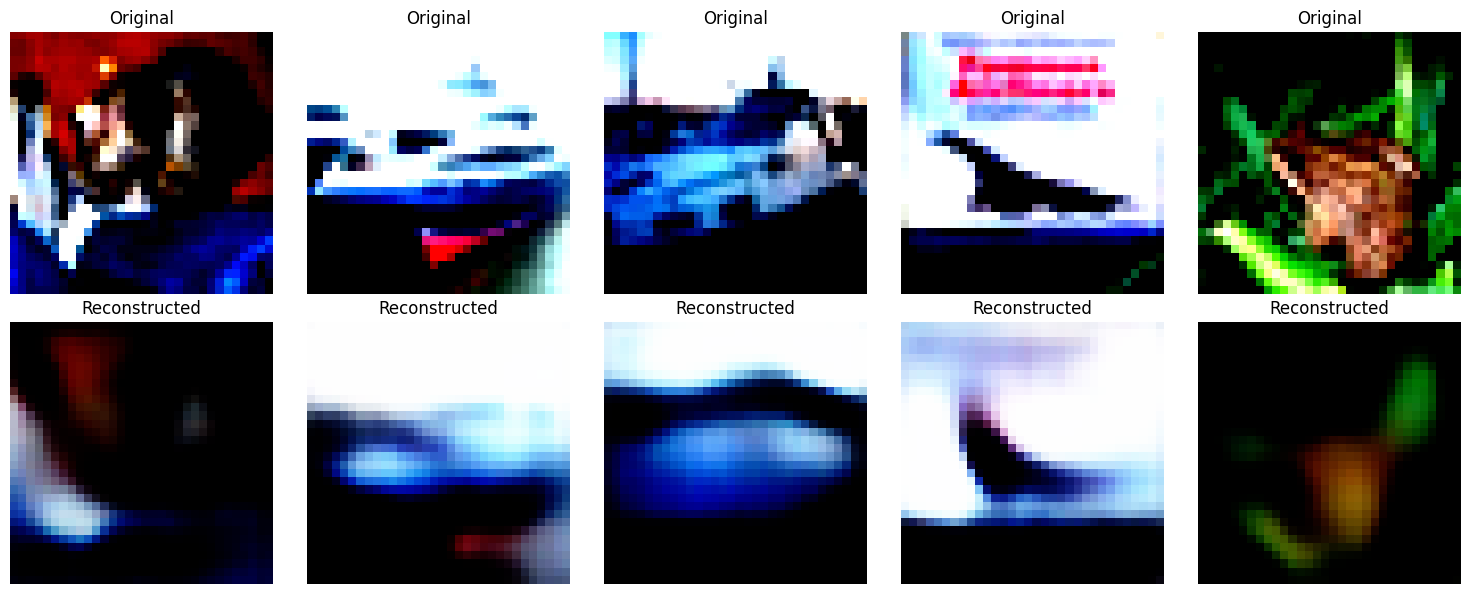

In [10]:
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

# Function to plot original vs reconstructed images and print mean reconstruction error
def plot_original_vs_reconstructed_with_error(model, data_loader, device):
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        # Get a batch of data
        for inputs, _ in data_loader:
            inputs = inputs.to(device)
            # Pass the inputs through the model
            reconstructed, _ = model(inputs)
            break  # Only process one batch

    # Compute reconstruction errors
    reconstruction_errors = F.mse_loss(reconstructed, inputs, reduction='none')  # Element-wise MSE
    reconstruction_errors = reconstruction_errors.view(reconstruction_errors.size(0), -1).mean(dim=1)  # Per-sample MSE
    mean_error = reconstruction_errors.mean().item()  # Compute the mean reconstruction error

    print(f"Mean Reconstruction Error: {mean_error:.6f}")

    # Move tensors to CPU for plotting
    inputs = inputs.cpu().numpy()
    reconstructed = reconstructed.cpu().numpy()

    # Denormalize the images (if normalized during preprocessing)
    inputs = np.transpose(inputs, (0, 2, 3, 1))  # Convert to HWC format
    reconstructed = np.transpose(reconstructed, (0, 2, 3, 1))  # Convert to HWC format

    # Plot original and reconstructed images
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))  # 2 rows, 5 columns
    for i in range(5):
        # Original image
        axes[0, i].imshow(np.clip(inputs[i], 0, 1))  # Clip values to [0, 1] for display
        axes[0, i].set_title("Original")
        axes[0, i].axis('off')

        # Reconstructed image
        axes[1, i].imshow(np.clip(reconstructed[i], 0, 1))  # Clip values to [0, 1] for display
        axes[1, i].set_title("Reconstructed")
        axes[1, i].axis('off')

    plt.tight_layout()
    plt.show()

# Example usage
plot_original_vs_reconstructed_with_error(model, test_loader, device)

In [ ]:

import importlib
import utils
importlib.reload(utils)
from utils import plot_tsne
plot_tsne(model.encoder, test_loader, device)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
import numpy as np


device = 'cuda' if torch.cuda.is_available() else 'cpu'
myencoder = model

myencoder.eval()


from torchvision import datasets, transforms

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])
train_val_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
batch_size = 256

train_size = int(0.8 * len(train_val_dataset))
val_size = len(train_val_dataset) - train_size
train_dataset, val_dataset = random_split(train_val_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


def extract_latent(loader, model, device):
    model.to(device)
    latent_vectors = []
    labels = []
    with torch.no_grad():
        for data, target in loader:
            data = data.to(device)
            features = model.encoder(data).flatten(1)
            latent = model.projection(features).cpu().numpy()
            latent_vectors.append(latent)
            labels.extend(target.numpy())
    latent_vectors = np.vstack(latent_vectors)
    labels = np.array(labels)
    return latent_vectors, labels


X_train, y_train = extract_latent(train_loader, myencoder, device)
X_test, y_test = extract_latent(test_loader, myencoder, device)
X_val, y_val = extract_latent(val_loader, myencoder, device)


X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)


train_dataset_latent = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset_latent = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset_latent = TensorDataset(X_test_tensor, y_test_tensor)
val_loader_latent = DataLoader(val_dataset_latent, batch_size=batch_size, shuffle=False)
train_loader_latent = DataLoader(train_dataset_latent, batch_size=batch_size, shuffle=True)
test_loader_latent = DataLoader(test_dataset_latent, batch_size=batch_size, shuffle=False)


Files already downloaded and verified
Files already downloaded and verified


In [8]:
class Classifier(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(Classifier, self).__init__()

        fc_dim = 512
        self.fc1 = nn.Linear(input_dim, fc_dim)
        self.bn1 = nn.BatchNorm1d(fc_dim)
        self.fc2 = nn.Linear(fc_dim, fc_dim)
        self.bn2 = nn.BatchNorm1d(fc_dim)
        self.fc3 = nn.Linear(fc_dim, num_classes)
        self.dropout = nn.Dropout(0.3)
    
    def forward(self, x):
        x = F.relu(self.bn1(self.fc1(x)))
        x = self.dropout(x)
        x = F.relu(self.bn2(self.fc2(x)))
        x = self.dropout(x)
        x = self.fc3(x)
        return x

Epoch 1/15
Train Loss: 1.1899 | Acc: 70.86%
Val Loss: 0.5585 | Acc: 88.39%
--------------------------------------------------
Epoch 2/15
Train Loss: 0.4574 | Acc: 88.81%
Val Loss: 0.4045 | Acc: 88.98%
--------------------------------------------------
Epoch 3/15
Train Loss: 0.3721 | Acc: 89.17%
Val Loss: 0.3568 | Acc: 89.37%
--------------------------------------------------
Epoch 4/15
Train Loss: 0.3417 | Acc: 89.41%
Val Loss: 0.3371 | Acc: 89.49%
--------------------------------------------------
Epoch 5/15
Train Loss: 0.3285 | Acc: 89.56%
Val Loss: 0.3286 | Acc: 89.64%
--------------------------------------------------
Epoch 6/15
Train Loss: 0.3219 | Acc: 89.67%
Val Loss: 0.3236 | Acc: 89.75%
--------------------------------------------------
Epoch 7/15
Train Loss: 0.3174 | Acc: 89.66%
Val Loss: 0.3193 | Acc: 89.73%
--------------------------------------------------
Epoch 8/15
Train Loss: 0.3143 | Acc: 89.76%
Val Loss: 0.3190 | Acc: 89.72%
-------------------------------------------

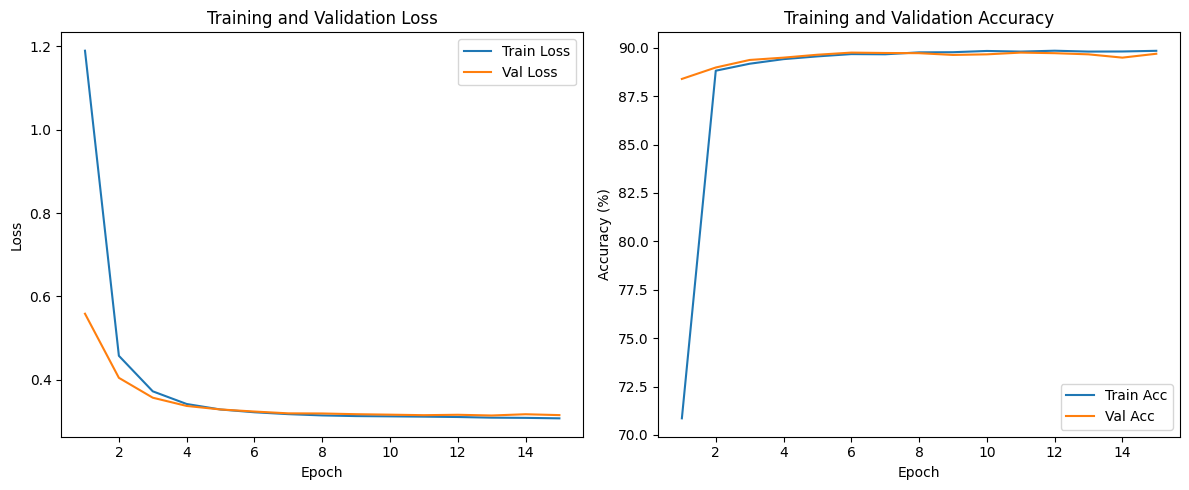

Test Results:
Loss: 0.6725 | Accuracy: 79.46%


In [27]:
import matplotlib.pyplot as plt

input_dim = 128
num_classes = 10
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
classifier = Classifier(input_dim, num_classes).to(device)
 

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(classifier.parameters(), lr=0.0001)
 

train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []
 
best_val_acc = 0.0
num_epochs = 15
 
for epoch in range(num_epochs):

    classifier.train()
    train_loss = 0.0
    correct_train = 0
    total_train = 0
   
    for inputs, labels in train_loader_latent:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = classifier(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        _, predicted = outputs.max(1)
        total_train += labels.size(0)
        correct_train += predicted.eq(labels).sum().item()
   

    classifier.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0
   
    with torch.no_grad():
        for inputs, labels in val_loader_latent:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = classifier(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = outputs.max(1)
            total_val += labels.size(0)
            correct_val += predicted.eq(labels).sum().item()
   

    train_acc = 100. * correct_train / total_train
    val_acc = 100. * correct_val / total_val
    avg_train_loss = train_loss / len(train_loader_latent)
    avg_val_loss = val_loss / len(val_loader_latent)
   

    train_losses.append(avg_train_loss)
    train_accuracies.append(train_acc)
    val_losses.append(avg_val_loss)
    val_accuracies.append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(classifier.state_dict(), 'best_classifier_new.pth')
   
    print(f'Epoch {epoch+1}/{num_epochs}')
    print(f'Train Loss: {avg_train_loss:.4f} | Acc: {train_acc:.2f}%')
    print(f'Val Loss: {avg_val_loss:.4f} | Acc: {val_acc:.2f}%')
    print('-' * 50)
 

plt.figure(figsize=(12, 5))
 

plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs+1), train_losses, label='Train Loss')
plt.plot(range(1, num_epochs+1), val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
 

plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs+1), train_accuracies, label='Train Acc')
plt.plot(range(1, num_epochs+1), val_accuracies, label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training and Validation Accuracy')
plt.legend()
 
plt.tight_layout()
plt.show()
 

classifier.load_state_dict(torch.load('best_classifier_new.pth'))
classifier.eval()
 
test_loss = 0.0
correct_test = 0
total_test = 0
 
with torch.no_grad():
    for inputs, labels in test_loader_latent:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = classifier(inputs)
        loss = criterion(outputs, labels)
        test_loss += loss.item()
        _, predicted = outputs.max(1)
        total_test += labels.size(0)
        correct_test += predicted.eq(labels).sum().item()
 
avg_test_loss = test_loss / len(test_loader_latent)
test_acc = 100. * correct_test / total_test
 
print(f'Test Results:')
print(f'Loss: {avg_test_loss:.4f} | Accuracy: {test_acc:.2f}%')